# EduTrack Exploratory Data Analysis (EDA)

## Overview
Comprehensive exploratory analysis of institutional data including:
- Distribution analysis
- Correlation analysis
- Institutional performance patterns
- Geographic analysis
- Risk assessment insights

In [3]:
import sys
import os

# Add project root to path (notebooks are in /notebooks subdirectory)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup visualization
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 7)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Cleaned Data

In [4]:
# Load cleaned data
data_path = os.path.join(project_root, 'data/processed/college_data_cleaned.csv')
df = pd.read_csv(data_path)

print(f"Loaded {len(df)} institutions with {len(df.columns)} fields")
print(f"\nFirst few records:")
df.head()

Loaded 4831 institutions with 20 fields

First few records:


,College Name,Genders Accepted,Campus Size,Total_Students,Total_Faculty,Established Year,Rating,University,Courses,Facilities,City,State,Country,College Type,Average Fees,Infrastructure_Area,Placement_Rate,Fund_Utilization,Avg_Doc_DSS,Missing_Doc_Count
0,National Institute Of Technology Rourkela,Co-Ed,647 Acres,4811,329,2007,3.12,Unknown,"B.Tech Mechanical Engineering, B.Tech Computer...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Rourkela,Odisha,India,Public/Government,350600.0,647.0,94.766550,91.221105,99.118126,0
1,Visvesvaraya National Institute Of Technology ...,Co-Ed,215 Acres,1071,192,2007,Unknown,Unknown,"B.Tech Computer Science Engineering, B.Tech El...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Nagpur,Maharashtra,India,Public/Government,273596.6666666667,215.0,97.804997,99.969437,97.432046,0
2,Netaji Subhas University Of Technology,Co-Ed,145 Acres,3759,101,2018,Unknown,Unknown,"B.Tech Computer Engineering, B.Tech Electronic...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",New Delhi,Delhi,India,Public/Government,352320.0,145.0,71.208414,67.662807,67.089073,0
3,Birla Institute Of Technology,Co-Ed,980 Acres,4506,284,1955,Unknown,Unknown,"B.Tech Computer Science Engineering, B.Tech El...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Ranchi,Jharkhand,India,Private,596686.0465116279,980.0,52.866463,53.433510,83.746910,2
4,International Institute Of Information Technology,Co-Ed,66 Acres,1721,85,2001,3.05,Unknown,"B.Tech Computer Science and Engineering, M.Tec...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Hyderabad,Telangana,India,Private,756666.6666666666,66.0,93.159041,90.456397,93.850100,0


## 2. Basic Statistics

In [5]:
# Summary statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("Key Metrics Summary:")
summary = df[numeric_cols].describe().round(2)
print(summary)

Key Metrics Summary:
       Total_Students  Total_Faculty  Infrastructure_Area  Placement_Rate  \
count         4831.00        4831.00              4831.00         4831.00   
mean          1816.74         101.62                46.72           60.62   
std          17652.54         116.62               252.25           12.17   
min              1.00           1.00                 0.00           40.04   
25%            504.00          43.00                23.00           50.43   
50%            812.00          72.00                23.00           60.44   
75%           1337.50         127.00                23.00           70.45   
max        1035081.00        2453.00             16000.00           98.89   

       Fund_Utilization  Avg_Doc_DSS  Missing_Doc_Count  
count           4831.00      4831.00            4831.00  
mean              67.95        62.88               0.39  
std               10.56        13.47               0.66  
min               50.00        40.03               0.

## 3. Placement Rate Distribution

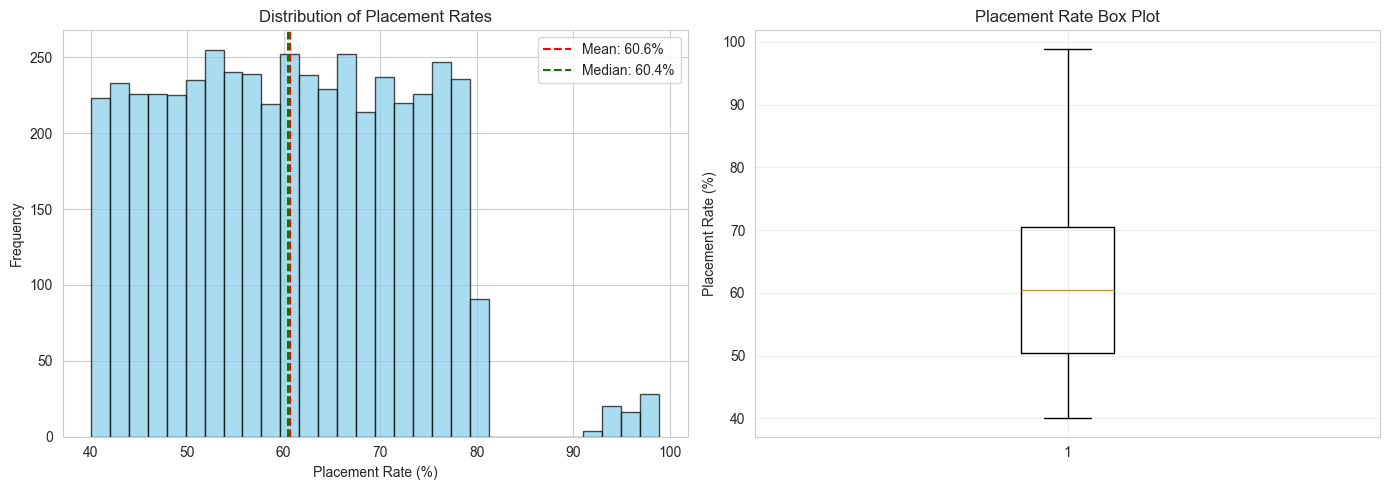

Placement Rate Statistics:
  Mean: 60.62%
  Median: 60.44%
  Std Dev: 12.17%
  Min: 40.04%, Max: 98.89%


In [6]:
# Placement rate analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Placement_Rate'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Placement Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Placement Rates')
axes[0].axvline(df['Placement_Rate'].mean(), color='red', linestyle='--', label=f"Mean: {df['Placement_Rate'].mean():.1f}%")
axes[0].axvline(df['Placement_Rate'].median(), color='green', linestyle='--', label=f"Median: {df['Placement_Rate'].median():.1f}%")
axes[0].legend()

# Box plot
axes[1].boxplot(df['Placement_Rate'])
axes[1].set_ylabel('Placement Rate (%)')
axes[1].set_title('Placement Rate Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Placement Rate Statistics:")
print(f"  Mean: {df['Placement_Rate'].mean():.2f}%")
print(f"  Median: {df['Placement_Rate'].median():.2f}%")
print(f"  Std Dev: {df['Placement_Rate'].std():.2f}%")
print(f"  Min: {df['Placement_Rate'].min():.2f}%, Max: {df['Placement_Rate'].max():.2f}%")

## 4. Student-Faculty Ratio Analysis

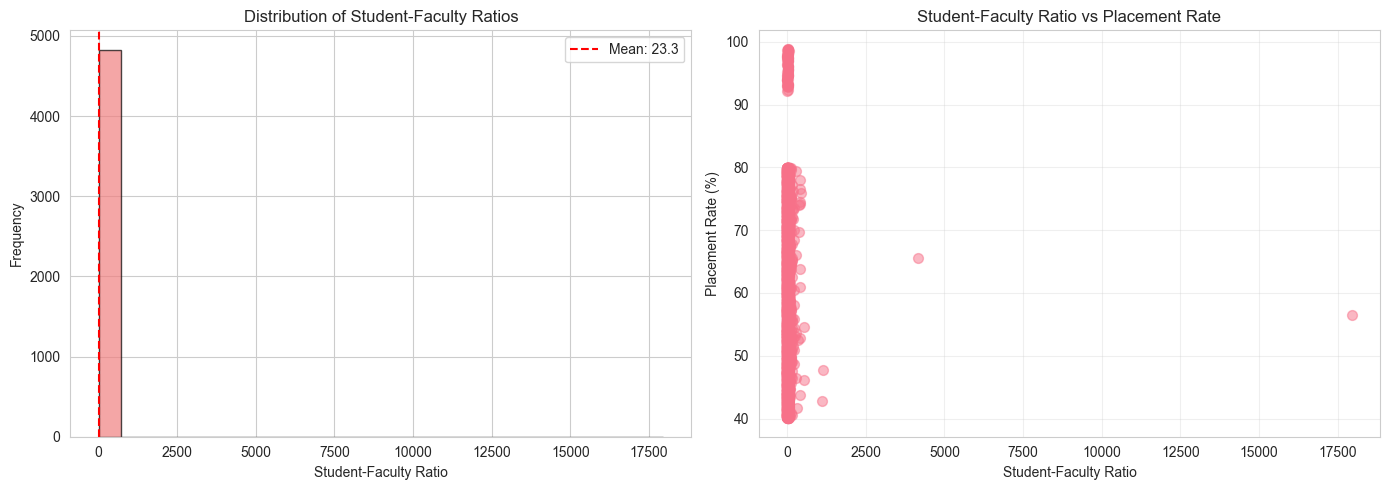

Correlation between S-F Ratio and Placement Rate: -0.006


In [7]:
# Calculate student-faculty ratio
df['Student_Faculty_Ratio'] = df['Total_Students'] / (df['Total_Faculty'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['Student_Faculty_Ratio'], bins=25, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Student-Faculty Ratio')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Student-Faculty Ratios')
axes[0].axvline(df['Student_Faculty_Ratio'].mean(), color='red', linestyle='--', label=f"Mean: {df['Student_Faculty_Ratio'].mean():.1f}")
axes[0].legend()

# Relationship with placement
axes[1].scatter(df['Student_Faculty_Ratio'], df['Placement_Rate'], alpha=0.5, s=50)
axes[1].set_xlabel('Student-Faculty Ratio')
axes[1].set_ylabel('Placement Rate (%)')
axes[1].set_title('Student-Faculty Ratio vs Placement Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
corr = df['Student_Faculty_Ratio'].corr(df['Placement_Rate'])
print(f"Correlation between S-F Ratio and Placement Rate: {corr:.3f}")

## 5. Infrastructure Analysis

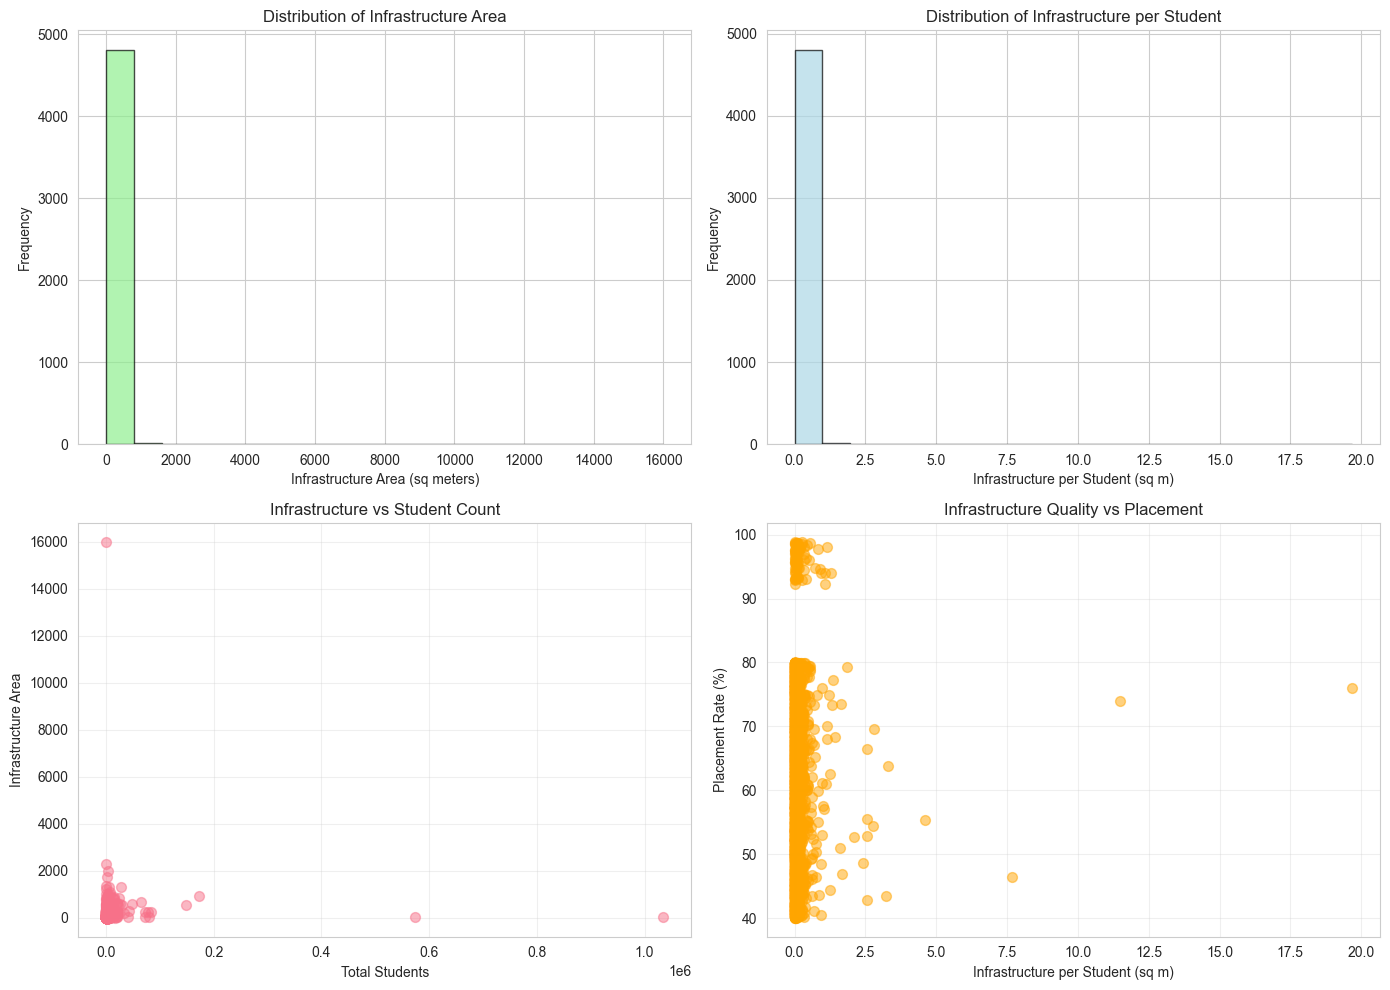

In [8]:
# Infrastructure per student
df['Infrastructure_Per_Student'] = df['Infrastructure_Area'] / (df['Total_Students'] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Infrastructure area
axes[0, 0].hist(df['Infrastructure_Area'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Infrastructure Area (sq meters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Infrastructure Area')

# Infrastructure per student
axes[0, 1].hist(df['Infrastructure_Per_Student'], bins=20, color='lightblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Infrastructure per Student (sq m)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Infrastructure per Student')

# Infrastructure vs students
axes[1, 0].scatter(df['Total_Students'], df['Infrastructure_Area'], alpha=0.5, s=50)
axes[1, 0].set_xlabel('Total Students')
axes[1, 0].set_ylabel('Infrastructure Area')
axes[1, 0].set_title('Infrastructure vs Student Count')
axes[1, 0].grid(True, alpha=0.3)

# Infrastructure vs placement
axes[1, 1].scatter(df['Infrastructure_Per_Student'], df['Placement_Rate'], alpha=0.5, s=50, color='orange')
axes[1, 1].set_xlabel('Infrastructure per Student (sq m)')
axes[1, 1].set_ylabel('Placement Rate (%)')
axes[1, 1].set_title('Infrastructure Quality vs Placement')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Compliance & DSS Analysis

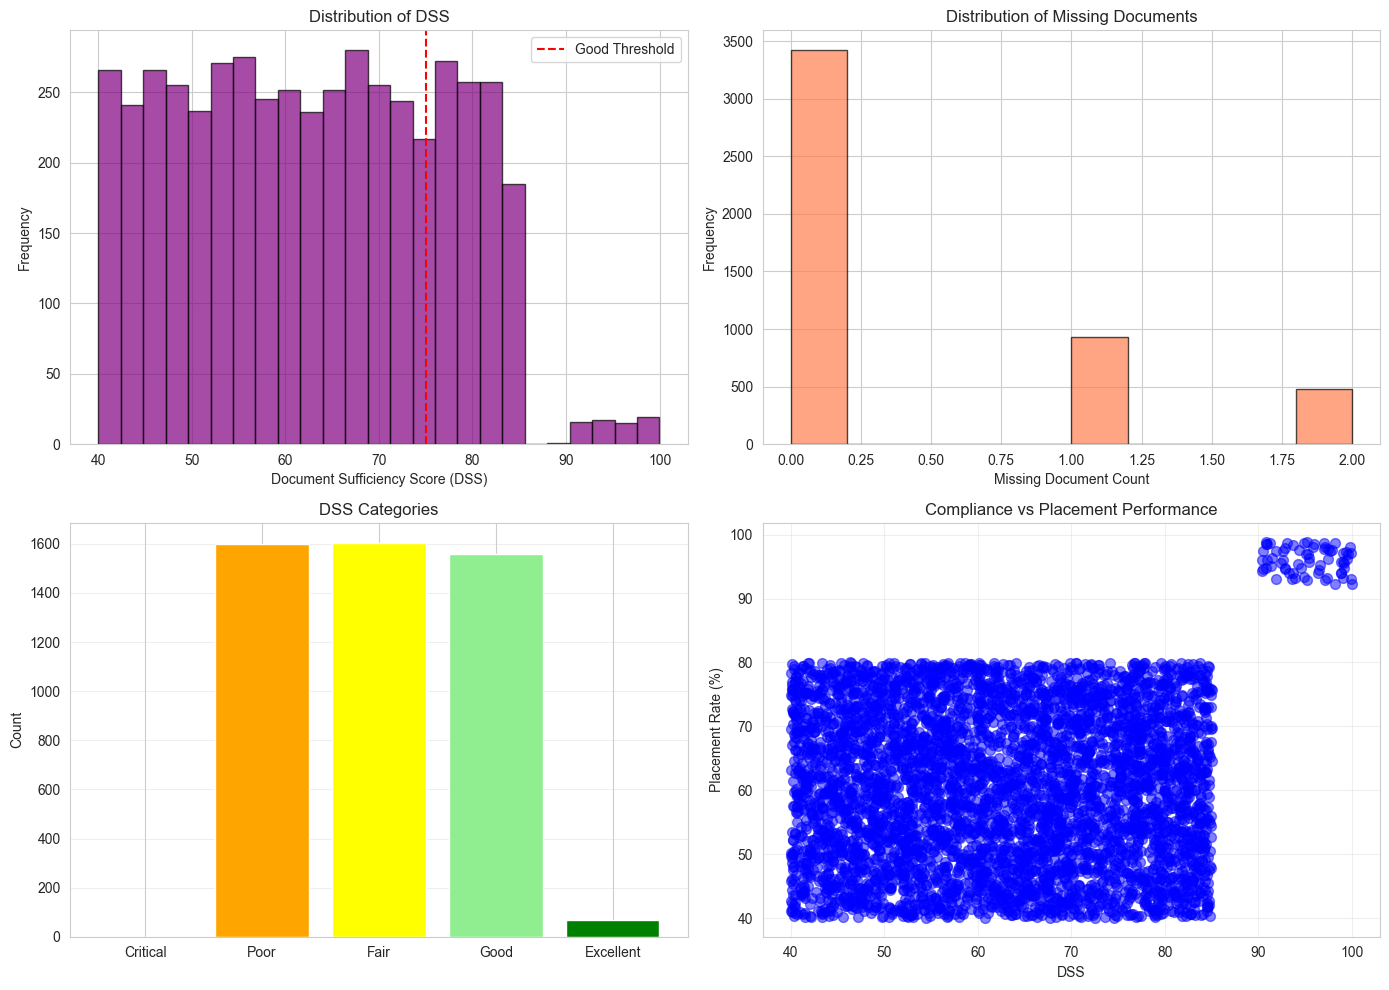


Compliance Summary:
Average DSS: 62.88
Institutions with DSS < 50: 1069 (22.1%)
Average Missing Docs: 0.39


In [9]:
# DSS and compliance analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DSS distribution
axes[0, 0].hist(df['Avg_Doc_DSS'], bins=25, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Document Sufficiency Score (DSS)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of DSS')
axes[0, 0].axvline(75, color='red', linestyle='--', label='Good Threshold')
axes[0, 0].legend()

# Missing documents
axes[0, 1].hist(df['Missing_Doc_Count'], bins=10, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Missing Document Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Missing Documents')

# DSS categories
dss_categories = pd.cut(df['Avg_Doc_DSS'], bins=[0, 40, 55, 70, 85, 100], 
                         labels=['Critical', 'Poor', 'Fair', 'Good', 'Excellent'])
dss_counts = dss_categories.value_counts().sort_index()
axes[1, 0].bar(range(len(dss_counts)), dss_counts.values, color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
axes[1, 0].set_xticks(range(len(dss_counts)))
axes[1, 0].set_xticklabels(dss_counts.index)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('DSS Categories')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# DSS vs placement
axes[1, 1].scatter(df['Avg_Doc_DSS'], df['Placement_Rate'], alpha=0.5, s=50, color='blue')
axes[1, 1].set_xlabel('DSS')
axes[1, 1].set_ylabel('Placement Rate (%)')
axes[1, 1].set_title('Compliance vs Placement Performance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCompliance Summary:")
print(f"Average DSS: {df['Avg_Doc_DSS'].mean():.2f}")
print(f"Institutions with DSS < 50: {(df['Avg_Doc_DSS'] < 50).sum()} ({(df['Avg_Doc_DSS'] < 50).sum()/len(df)*100:.1f}%)")
print(f"Average Missing Docs: {df['Missing_Doc_Count'].mean():.2f}")

## 7. Fund Utilization Analysis

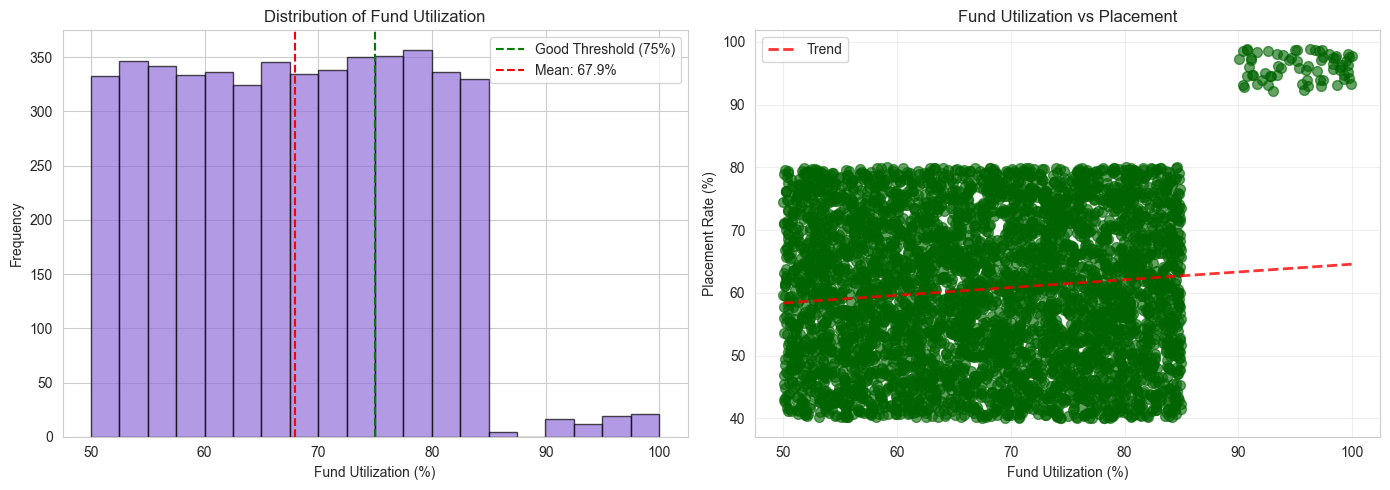

Fund Utilization Statistics:
  Mean: 67.95%
  Good (≥75%): 1445 institutions
  Poor (<60%): 1356 institutions


In [10]:
# Fund utilization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['Fund_Utilization'], bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].axvline(75, color='green', linestyle='--', label='Good Threshold (75%)')
axes[0].axvline(df['Fund_Utilization'].mean(), color='red', linestyle='--', label=f"Mean: {df['Fund_Utilization'].mean():.1f}%")
axes[0].set_xlabel('Fund Utilization (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Fund Utilization')
axes[0].legend()

# Fund utilization vs placement
axes[1].scatter(df['Fund_Utilization'], df['Placement_Rate'], alpha=0.6, s=50, color='darkgreen')
z = np.polyfit(df['Fund_Utilization'], df['Placement_Rate'], 1)
p = np.poly1d(z)
axes[1].plot(df['Fund_Utilization'].sort_values(), p(df['Fund_Utilization'].sort_values()), "r--", alpha=0.8, linewidth=2, label='Trend')
axes[1].set_xlabel('Fund Utilization (%)')
axes[1].set_ylabel('Placement Rate (%)')
axes[1].set_title('Fund Utilization vs Placement')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fund Utilization Statistics:")
print(f"  Mean: {df['Fund_Utilization'].mean():.2f}%")
print(f"  Good (≥75%): {(df['Fund_Utilization'] >= 75).sum()} institutions")
print(f"  Poor (<60%): {(df['Fund_Utilization'] < 60).sum()} institutions")

## 8. Correlation Matrix

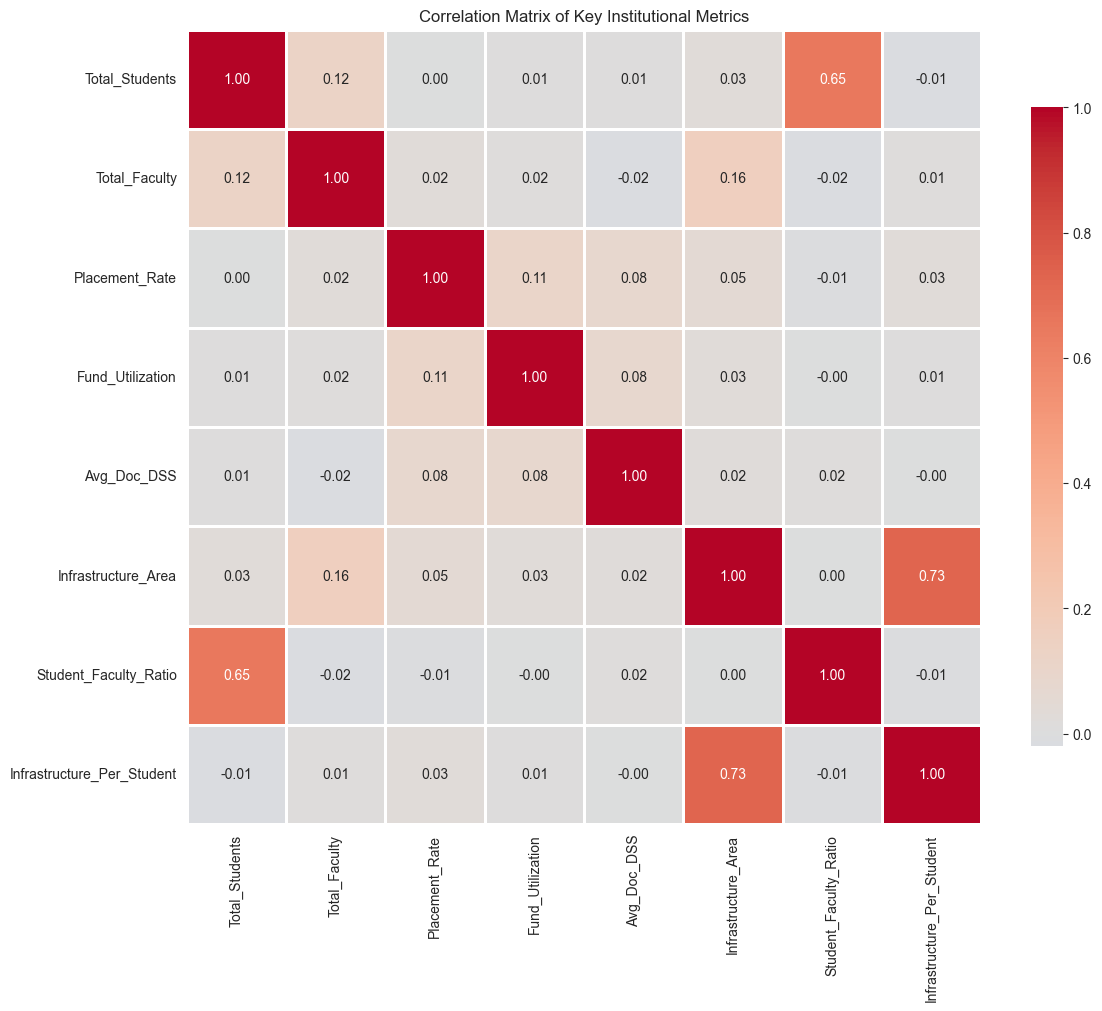


Key Correlations with Placement Rate:
Placement_Rate                1.000000
Fund_Utilization              0.107455
Avg_Doc_DSS                   0.082804
Infrastructure_Area           0.047845
Infrastructure_Per_Student    0.028447
Total_Faculty                 0.024552
Total_Students                0.001341
Student_Faculty_Ratio        -0.005630
Name: Placement_Rate, dtype: float64


In [11]:
# Calculate correlations
numeric_cols = ['Total_Students', 'Total_Faculty', 'Placement_Rate', 'Fund_Utilization', 
                 'Avg_Doc_DSS', 'Infrastructure_Area', 'Student_Faculty_Ratio', 'Infrastructure_Per_Student']

corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Institutional Metrics')
plt.tight_layout()
plt.show()

# Print key correlations
print("\nKey Correlations with Placement Rate:")
placement_corr = corr_matrix['Placement_Rate'].sort_values(ascending=False)
print(placement_corr)

## 9. Geographic Distribution

## 10. Key Insights & Recommendations

In [12]:
# Generate insights
insights = {
    'Total Institutions': len(df),
    'Avg Placement Rate': f"{df['Placement_Rate'].mean():.1f}%",
    'Avg DSS': f"{df['Avg_Doc_DSS'].mean():.1f}",
    'High Risk Institutions': (df['Avg_Doc_DSS'] < 50).sum(),
    'Low Placement Institutions': (df['Placement_Rate'] < 50).sum(),
    'Avg Fund Utilization': f"{df['Fund_Utilization'].mean():.1f}%"
}

print("\n" + "="*50)
print("KEY INSIGHTS FROM DATA")
print("="*50)
for key, value in insights.items():
    print(f"{key:.<35} {value}")

print("\n" + "="*50)
print("RECOMMENDATIONS")
print("="*50)
print(f"1. Focus on {(df['Avg_Doc_DSS'] < 50).sum()} institutions with critical compliance issues")
print(f"2. Support {(df['Placement_Rate'] < 50).sum()} institutions with low placement rates")
print(f"3. Investigate fund utilization patterns (Mean: {df['Fund_Utilization'].mean():.1f}%)")
print(f"4. Optimize infrastructure: {(df['Infrastructure_Per_Student'] < 2).sum()} institutions below standards")


KEY INSIGHTS FROM DATA
Total Institutions................. 4831
Avg Placement Rate................. 60.6%
Avg DSS............................ 62.9
High Risk Institutions............. 1069
Low Placement Institutions......... 1147
Avg Fund Utilization............... 67.9%

RECOMMENDATIONS
1. Focus on 1069 institutions with critical compliance issues
2. Support 1147 institutions with low placement rates
3. Investigate fund utilization patterns (Mean: 67.9%)
4. Optimize infrastructure: 4817 institutions below standards
